## Regression II: multiple variables linear regression


In the previous practice of single variable regression, we minimize:

$$\min \big(y_i- (ax_i+b) \big)^2.$$

The same concept extends to multiple variable regression. For instance, for a linear function:

$$z = ax + by +c,$$

we have 2 variables: $x$ and $y$. Or in statistic jargons, we can express it as

$$y = a x_1 + b x_2 + c,$$

with variables $x_1$ and $x_2$.

<img src="https://i.ibb.co/sdFLhpxQ/multiple-linear-regression-plane.png&px=400"> 

*- Image from internet*

Now, the objective function becomes

$$\min \big(y_i- (ax_{1,i} +bx_{2,i} +c) \big)^2,$$

where $i$ is the index of the $i$-th data point. We are finding the plane that minimizes the objective function. In matrix form, we still have

$$\min_\beta || \mathbf{X} \beta - \mathbf{y} ||^2,$$

but 

$$\mathbf{X} = \begin{bmatrix} 1 & x_{1,1} & x_{2,1} \\  1 & x_{1,2} & x_{2,2} \\ . \\ . \\  1 & x_{1,n} & x_{2,n} \end{bmatrix}.$$

We can use `OLS` for multiple variables regression.


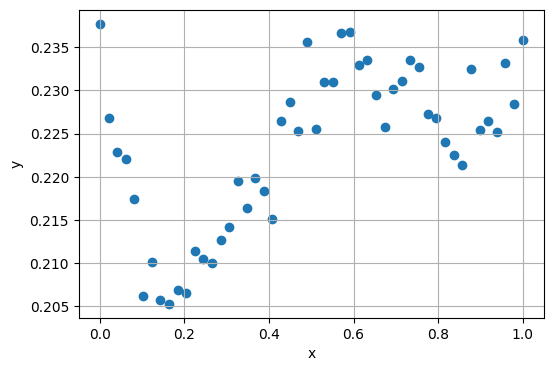

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# reproducibility
np.random.seed(0)

# x values
x = np.linspace(0, 1, 50)

# true line
y_true = ((x-0.2)**2 * (0.9-x)**2)*1 + (0.03*x + 0.2)*1

# add random noise
noise = np.random.normal(loc=0, scale=0.003, size=len(x))

y = y_true + noise

plt.figure(figsize=(6,4))

plt.scatter(x, y)

plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

### Making the Polynomial Features

Now, it would be nice to do our work for multiple variables using a `pandas` DataFrame so that we have the opportunity to label our columns. There's the added benefit that `statsmodels` works well with `pandas` DataFrames. 

For a 4th-order polynomial, 

$$y = ax^4 + b x^3 + c x^2 + d x + e,$$

we can view it as

$$y = a x_4 + b x_3 + c x_2 + d x_1 + e,$$

where $x_i = x^i$.

**Make a DataFrame consisting of the following columns**: a constant value for the intercept, the values in `x1`, and additional powers of `x1` up to 4.

You can do this by
- adding columns to the `x1` array and then finish off by adding to a DataFrame
- use `np.insert` method

To state the goal for this task again, the columns of the DataFrame should be:
* Label the first column "const" and just place the value 1 in it
* make the `x1` data column 1, labeled "data"
* the next 3 columns should be based on `x1` and have as values: $x^2$, $x^3$, and $x^4$. Give them good (but short) label names

Print the head of your DataFrame when you're done to make sure it looks right. 

In [4]:
import pandas as pd

x1 = x.reshape(-1,1)
X = np.insert(x1, 0, 1, axis=1)

for i in range(2,5):
    X = np.insert(X, i, X[:,1]**i, axis=1)

# X
df = pd.DataFrame(X, columns=["const", "data", "sqr", "cube", "quad"])
df.head()

,const,data,sqr,cube,quad
0,1.0,0.000000,0.000000,0.000000,0.000000e+00
1,1.0,0.020408,0.000416,0.000008,1.734665e-07
2,1.0,0.040816,0.001666,0.000068,2.775464e-06
3,1.0,0.061224,0.003748,0.000229,1.405079e-05
4,1.0,0.081633,0.006664,0.000544,4.440743e-05


In [6]:
import statsmodels.api as sm

model = sm.OLS(y, df)
results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.890
Model:                            OLS   Adj. R-squared:                  0.881
Method:                 Least Squares   F-statistic:                     91.27
Date:                Sun, 17 May 2026   Prob (F-statistic):           5.38e-21
Time:                        14:36:43   Log-Likelihood:                 217.90
No. Observations:                  50   AIC:                            -425.8
Df Residuals:                      45   BIC:                            -416.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2368      0.002    115.094      0.000       0.233       0.241
data          -0.3959      0.029    -13.594      0.000      -0.455      -0.337
sqr            1.6537      0.120     13.759      0.000       1.412       1.896
cube          -2.2997      0.181    -12.673      0.000      -2.665      -1.934
quad           1.0399      0.090     11.555      0.000       0.859       1.221
==============================================================================
Omnibus:                        0.224   Durbin-Watson:                   2.127
Prob(Omnibus):                  0.894   Jarque-Bera (JB):                0.037
Skew:                          -0.067   Prob(JB):                        0.981
Kurtosis:                       3.000   Cond. No.                         643.
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

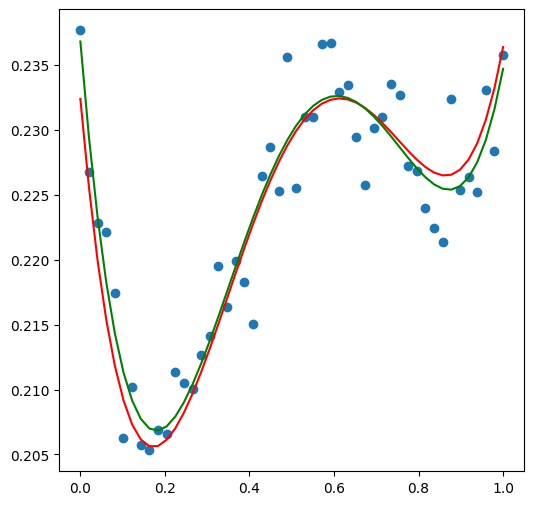

In [104]:
fig = plt.figure(figsize=(6,6))

plt.scatter(x, y)
plt.plot(x, y_true, 'r-')

plt.plot(x1, results.predict(), 'g-')